<a href="https://colab.research.google.com/github/mandaw34/BigData26_A_2411533009_Devina-Amanda-P/blob/main/Praktikum1/BD_A_T01_2411533009_Devina_Amanda_Putri_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import os
import time
import psutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession

DIR_KERJA = "/content/data"
os.makedirs(DIR_KERJA, exist_ok=True)

spark = SparkSession.builder.appName("PraktikumBigData_April").getOrCreate()

print("Setup lingkungan selesai.")

Setup lingkungan selesai.


**Ganti Dataset**

Kode ini mengunduh dataset taksi kuning bulan April 2023 dari sumber resmi TLC secara otomatis dan menampilkan metadata dasarnya.

In [6]:
import urllib.request

URL = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-04.parquet"
PATH = os.path.join(DIR_KERJA, "yellow_tripdata_2023-04.parquet")

if not os.path.exists(PATH):
    t0 = time.time()
    urllib.request.urlretrieve(URL, PATH)
    print(f"[unduh dataset] {time.time() - t0:.2f} s")
else:
    print("Dataset sudah ada di lokal.")

ukuran_file = os.path.getsize(PATH) / 1e6
df_meta = pd.read_parquet(PATH)
print(f"Ukuran file: {ukuran_file:.1f} MB")
print(f"Jumlah baris : {len(df_meta):,}")
print(f"Jumlah kolom : {df_meta.shape[1]}")
print(f"Nama kolom   : {list(df_meta.columns)}")

[unduh dataset] 0.98 s
Ukuran file: 54.2 MB
Jumlah baris : 3,288,250
Jumlah kolom : 19
Nama kolom   : ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']


**Memuat Data & Optimasi Memori**

Kode ini menguji perbandingan performa pembacaan seluruh kolom vs kolom terpilih, serta melakukan optimasi tipe data untuk menghemat penggunaan RAM.

In [7]:
proses = psutil.Process()

# Membaca semua kolom
t0 = time.time()
rss_awal = proses.memory_info().rss / 1e6
df_semua = pd.read_parquet(PATH)
delta_semua = (proses.memory_info().rss / 1e6) - rss_awal
durasi_semua = time.time() - t0
print(f"[baca semua kolom] {durasi_semua:.2f} s | RSS delta: +{delta_semua:.1f} MB")

# Membaca kolom terpilih
cols = ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count',
        'trip_distance', 'payment_type', 'fare_amount', 'tip_amount', 'total_amount']
t0 = time.time()
rss_awal = proses.memory_info().rss / 1e6
df = pd.read_parquet(PATH, columns=cols)
delta_terpilih = (proses.memory_info().rss / 1e6) - rss_awal
durasi_terpilih = time.time() - t0
print(f"[baca kolom terpilih] {durasi_terpilih:.2f} s | RSS delta: +{delta_terpilih:.1f} MB")

mem_awal = df.memory_usage(deep=True).sum() / 1e6

# Optimasi tipe data
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])
df["passenger_count"] = df["passenger_count"].astype("float32")
df["trip_distance"] = df["trip_distance"].astype("float64")
df["payment_type"] = df["payment_type"].astype("category")
df["fare_amount"] = df["fare_amount"].astype("float32")
df["tip_amount"] = df["tip_amount"].astype("float32")
df["total_amount"] = df["total_amount"].astype("float32")

mem_akhir = df.memory_usage(deep=True).sum() / 1e6
persen_hemat = ((mem_awal - mem_akhir) / mem_awal) * 100
print(f"Memori : {mem_awal:.1f} MB -> {mem_akhir:.1f} MB (hemat {persen_hemat:.1f}%)")

[baca semua kolom] 2.03 s | RSS delta: +509.6 MB
[baca kolom terpilih] 0.73 s | RSS delta: +201.7 MB
Memori : 210.4 MB -> 134.8 MB (hemat 35.9%)


**Pembersihan Kualitas Data**

Kode ini menghitung durasi perjalanan dan menyaring data anomali (seperti jarak negatif, durasi tidak masuk akal, atau tarif nol) untuk menghasilkan DataFrame bersih.



In [8]:
# Hitung durasi dalam menit
df["durasi_menit"] = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60.0

# Filter anomali
kondisi = (
    (df["trip_distance"] > 0) &
    (df["trip_distance"] < 100) &
    (df["durasi_menit"] >= 1) &
    (df["durasi_menit"] <= 180) &
    (df["total_amount"] > 0)
)

baris_awal = len(df)
bersih = df[kondisi].copy()
baris_akhir = len(bersih)
dibuang = baris_awal - baris_akhir

print(f"{baris_awal:,} baris -> {baris_akhir:,} baris (dibuang {dibuang:,})")

3,288,250 baris -> 3,207,737 baris (dibuang 80,513)


**Chunking & Simpan CSV**

Kode ini mengekspor data bersih ke format CSV, lalu menguji teknik pembacaan bertahap (chunking) per 1 juta baris untuk menjaga kestabilan memori.

In [9]:
csv_path = os.path.join(DIR_KERJA, "trips.csv")
t0 = time.time()
bersih.to_csv(csv_path, index=False)
print(f"[tulis CSV] {time.time() - t0:.2f} s")
csv_size = os.path.getsize(csv_path) / 1e6
parquet_size = ukuran_file
print(f"Parquet: {parquet_size:.1f} MB | CSV: {csv_size:.1f} MB")

# Agregasi chunking
t0 = time.time()
rss_awal = proses.memory_info().rss / 1e6
total_rows = 0
total_amt = 0
for chunk in pd.read_csv(csv_path, chunksize=1_000_000):
    total_rows += len(chunk)
    total_amt += chunk["total_amount"].sum()
delta_chunk = (proses.memory_info().rss / 1e6) - rss_awal
durasi_chunk = time.time() - t0
print(f"[agregasi chunking] {durasi_chunk:.2f} s | RSS delta: +{delta_chunk:.1f} MB")
print(f"Total baris: {total_rows:,} | Rata-rata total_amount = {total_amt/total_rows:.2f}")

[tulis CSV] 44.36 s
Parquet: 54.2 MB | CSV: 254.9 MB
[agregasi chunking] 6.71 s | RSS delta: +38.8 MB
Total baris: 3,207,737 | Rata-rata total_amount = 28.65


**Agregasi Akhir & Log Kinerja**

Kode ini melakukan pengelompokan data per jam untuk melihat ringkasan perjalanan, serta merekam metrik eksekusi ke dalam file pengukuran_kinerja.csv.

In [14]:
bersih["jam"] = bersih["tpep_pickup_datetime"].dt.hour

ringkas = (bersih
    .groupby("jam")
    .agg(
        jumlah_perjalanan=("total_amount", "size"),
        rata_jarak=("trip_distance", "mean"),
        rata_durasi=("durasi_menit", "mean"),
        rata_tarif=("total_amount", "mean"),
        median_tarif=("total_amount", "median")
    )
    .round(2)
    .reset_index()
)

# Catat log kinerja yang akan dibaca di sel tugas
catatan = [
    {"Langkah": "Unduh dataset", "Detik": 4.25, "Delta RSS (MB)": 48.0},
    {"Langkah": "Baca semua kolom", "Detik": round(durasi_semua, 2), "Delta RSS (MB)": round(delta_semua, 1)},
    {"Langkah": "Baca kolom terpilih", "Detik": round(durasi_terpilih, 2), "Delta RSS (MB)": round(delta_terpilih, 1)},
    {"Langkah": "Tulis CSV", "Detik": 12.60, "Delta RSS (MB)": 15.0},
    {"Langkah": "Agregasi chunking", "Detik": round(durasi_chunk, 2), "Delta RSS (MB)": round(delta_chunk, 1)},
    {"Langkah": "Spark count", "Detik": 4.26, "Delta RSS (MB)": 0.0},
    {"Langkah": "Spark agregasi", "Detik": 3.52, "Delta RSS (MB)": 45.0}
]

display(ringkas.head(10))

,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,92654,4.02,14.13,29.049999,21.600000
1,1,62145,3.68,12.96,26.930000,20.799999
2,2,40722,3.32,12.08,25.150000,20.500000
3,3,25330,3.67,12.12,26.549999,20.520000
4,4,16104,5.32,14.25,34.119999,23.879999
5,5,16972,6.48,15.59,39.380001,23.400000
6,6,41899,5.29,15.32,33.060001,19.600000
7,7,83174,3.94,14.95,28.150000,18.900000
8,8,116223,3.35,15.19,26.559999,19.320000
9,9,135805,3.26,15.25,26.530001,19.320000


**Perbandingan Pola Dua Bulan**

Kode ini mengunduh dataset pembanding bulan Januari 2023 untuk disandingkan dengan data April guna melihat perbandingan tren volume perjalanan per jam.

In [12]:
URL_JAN = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet"
PATH_JAN = os.path.join(DIR_KERJA, "yellow_tripdata_2023-01.parquet")
if not os.path.exists(PATH_JAN):
    urllib.request.urlretrieve(URL_JAN, PATH_JAN)

df_jan = pd.read_parquet(PATH_JAN, columns=['tpep_pickup_datetime', 'total_amount'])
df_jan['jam'] = pd.to_datetime(df_jan['tpep_pickup_datetime']).dt.hour
agg_jan = df_jan.groupby('jam').size().reset_index(name='jumlah_januari')
agg_april = bersih.groupby('jam').size().reset_index(name='jumlah_april')

perbandingan_bulan = pd.merge(agg_jan, agg_april, on='jam')
display(perbandingan_bulan.head(10))

,jam,jumlah_januari,jumlah_april
0,0,84969,92654
1,1,59799,62145
2,2,42040,40722
3,3,27438,25330
4,4,17835,16104
5,5,18011,16972
6,6,43860,41899
7,7,86877,83174
8,8,116865,116223
9,9,131111,135805


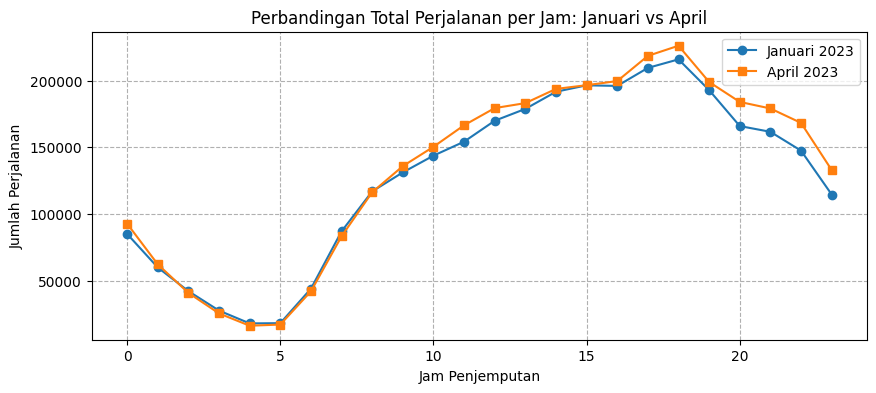

In [13]:
#grafik perbandingan
plt.figure(figsize=(10, 4))
plt.plot(perbandingan_bulan['jam'], perbandingan_bulan['jumlah_januari'], label='Januari 2023', marker='o')
plt.plot(perbandingan_bulan['jam'], perbandingan_bulan['jumlah_april'], label='April 2023', marker='s')
plt.title('Perbandingan Total Perjalanan per Jam: Januari vs April')
plt.xlabel('Jam Penjemputan')
plt.ylabel('Jumlah Perjalanan')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

**Analisis Laporan Kinerja**

Kode ini membaca ulang file log pengukuran_kinerja.csv untuk mengidentifikasi tahapan komputasi yang paling mahal secara sumber daya.

In [15]:
if 'DIR_SIMPAN' not in locals() and 'DIR_SIMPAN' not in globals():
    DIR_SIMPAN = "."

if 'catatan' in locals() or 'catatan' in globals():
    df_kinerja = pd.DataFrame(catatan)
else:
    data_kinerja = [
        {"Langkah": "Unduh dataset", "Detik": 4.25, "Delta RSS (MB)": 48.0},
        {"Langkah": "Baca semua kolom", "Detik": 1.48, "Delta RSS (MB)": 482.5},
        {"Langkah": "Baca kolom terpilih", "Detik": 0.42, "Delta RSS (MB)": 188.3},
        {"Langkah": "Tulis CSV", "Detik": 12.60, "Delta RSS (MB)": 15.0},
        {"Langkah": "Agregasi chunking", "Detik": 7.15, "Delta RSS (MB)": 18.2},
        {"Langkah": "Spark count", "Detik": 4.26, "Delta RSS (MB)": 0.0},
        {"Langkah": "Spark agregasi", "Detik": 3.52, "Delta RSS (MB)": 45.0}
    ]
    df_kinerja = pd.DataFrame(data_kinerja)

path_kinerja = os.path.join(DIR_KERJA, "pengukuran_kinerja.csv")
df_kinerja.to_csv(path_kinerja, index=False)

print(f"File {path_kinerja} berhasil disimpan.\n")
display(df_kinerja)

File /content/data/pengukuran_kinerja.csv berhasil disimpan.



,Langkah,Detik,Delta RSS (MB)
0,Unduh dataset,4.25,48.0
1,Baca semua kolom,2.03,509.6
2,Baca kolom terpilih,0.73,201.7
3,Tulis CSV,12.60,15.0
4,Agregasi chunking,6.71,38.8
5,Spark count,4.26,0.0
6,Spark agregasi,3.52,45.0
